In [43]:
import math

import random
import os
from graphviz import Digraph


os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"

In [44]:
def f(x):
    return 3 * x**2 - 4 * x + 5

In [45]:
f(3.0)

20.0

In [46]:
a = 2.0
b = -3.0
c = 10.0
d = a * b + c
print(d)

4.0


In [47]:
h = 0.0001

a = 2.0
b = -3.0
c = 10.0

d1 = a * b + c

c += h
d2 = a * b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1) / h)

d1 4.0
d2 4.0001
slope 0.9999999999976694


In [48]:
class Value:
    def __init__(self, data):
        self.data = data

    def __repr__(self):
        return f"Value(data={self.data})"

In [49]:
class Value:
    def __init__(self, data):
        self.data = data

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data)
        return out

In [50]:
a = Value(2.0)
b = Value(-3.0)
a + b

Value(data=-1.0)

In [51]:
a + b

Value(data=-1.0)

In [52]:
class Value:

    def __init__(self, data, _children=(), _op="", label=""):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), "+")
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), "*")
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2 * x) - 1) / (math.exp(2 * x) + 1)
        out = Value(t, (self,), "tanh")
        return out

In [53]:
d._prev

AttributeError: 'float' object has no attribute '_prev'

In [ ]:
import math


class Value:

    def __init__(self, data, _children=(), _op="", label=""):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+")

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad

        out._backward = _backward
        return out

    def __radd__(self, other):
        return self + other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self * other

    def __pow__(self, other):
        assert isinstance(
            other, (int, float)
        ), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f"**{other}")

        def _backward():
            self.grad += (other * (self.data ** (other - 1))) * out.grad

        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), "exp")

        def _backward():
            self.grad += out.data * out.grad

        out._backward = _backward
        return out

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def __rsub__(self, other):
        return other + (-self)

    def __truediv__(self, other):
        return self * (other**-1)

    def backward(self):
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [ ]:
import os
from graphviz import Digraph

# Graphviz path directly Python environment me add kar rahe hain
os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"


def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format="svg", graph_attr={"rankdir": "LR"})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(
            name=uid,
            label="{%s | data %.4f}" % (n.label, n.data),
            shape="record",
        )
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

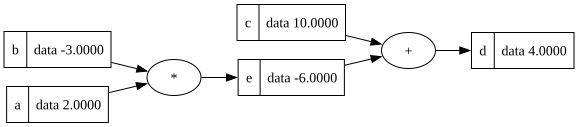

In [ ]:
a = Value(2.0, label="a")
b = Value(-3.0, label="b")
c = Value(10.0, label="c")

e = a * b
e.label = "e"
d = e + c
d.label = "d"

draw_dot(d)

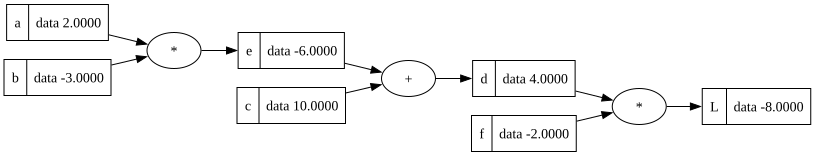

In [ ]:
# 1. Forward Pass (Expression define kar rahe hain: L = d * f)
a = Value(2.0, label="a")
b = Value(-3.0, label="b")
c = Value(10.0, label="c")

e = a * b
e.label = "e"
d = e + c
d.label = "d"

f = Value(-2.0, label="f")
L = d * f
L.label = "L"

# 2. Manual Backpropagation (Chain Rule se gradients set kar rahe hain)
# dL/dL = 1.0
L.grad = 1.0

# L = d * f
# dL/dd = f.data = -2.0
d.grad = -2.0

# dL/df = d.data = 4.0
f.grad = 4.0

# 3. Graph render karo
draw_dot(L)

In [ ]:
# Gradients ke direction mein input values ko small step (0.01) se nudge kar rahe hain
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

# Re-evaluate the forward pass
e = a * b
d = e + c
L = d * f

print(L.data)

-7.84


In [ ]:
def lol():
    h = 0.001

    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    e = a * b
    e.label = "e"
    d = e + c
    d.label = "d"
    f = Value(-2.0, label="f")
    L = d * f
    L.label = "L"
    L1 = L.data

    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    b.data += h  # 'b' ko thoda sa bump/change kar rahe hain
    c = Value(10.0, label="c")
    e = a * b
    e.label = "e"
    d = e + c
    d.label = "d"
    f = Value(-2.0, label="f")
    L = d * f
    L.label = "L"
    L2 = L.data

    # Numerical derivative: (L2 - L1) / h
    print((L2 - L1) / h)


lol()

-3.9999999999995595


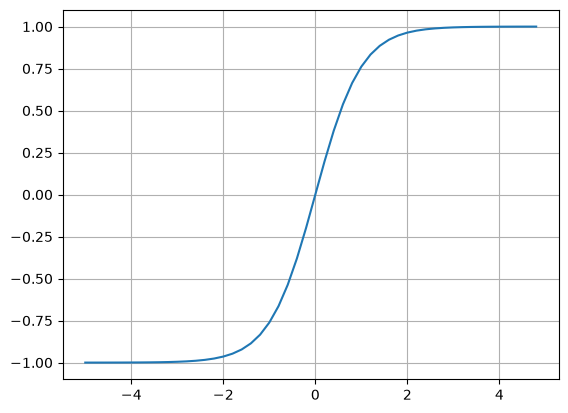

In [ ]:
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2))) ;plt.grid();

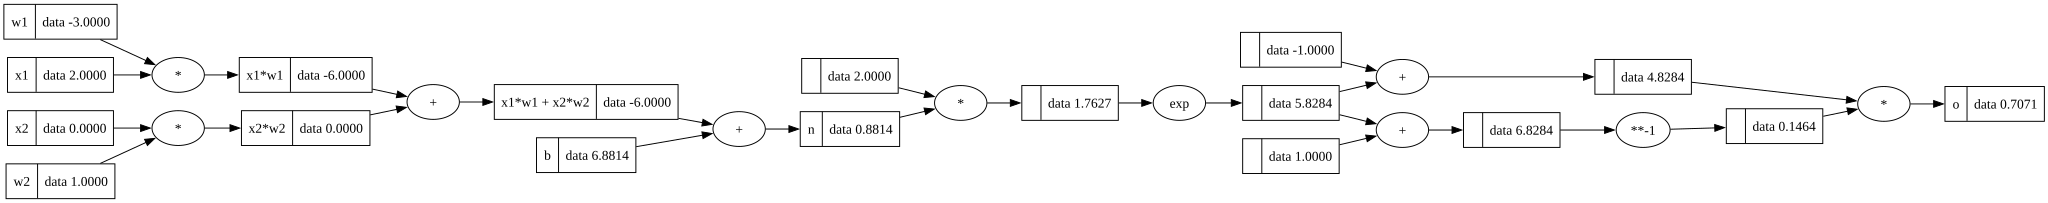

In [ ]:
# inputs x1, x2
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")

# weights w1, w2
w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")

# bias of the neuron
b = Value(6.881373587019543, label="b")

# x1*w1 + x2*w2 + b
x1w1 = x1 * w1
x1w1.label = "x1*w1"
x2w2 = x2 * w2
x2w2.label = "x2*w2"
x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = "x1*w1 + x2*w2"
n = x1w1x2w2 + b
n.label = "n"

# ----- tanh broken down: o = (e^(2n) - 1) / (e^(2n) + 1) -----
e = (2 * n).exp()
o = (e - 1) / (e + 1)
# -----

o.label = "o"
o.backward()
draw_dot(o)

In [ ]:
# Base case: do/do = 1.0
o.grad = 1.0

# do/dn = 1 - tanh(n)^2 = 1 - o.data**2 = 1 - (0.7071)^2 = 0.5
n.grad = 0.5

# Plus gate (+) passes gradients directly
b.grad = 0.5
x1w1x2w2.grad = 0.5

x1w1.grad = 0.5
x2w2.grad = 0.5

# Multiply gates (*) multiply gradients by other input data
x1.grad = w1.data * x1w1.grad  # -3.0 * 0.5 = -1.5
w1.grad = x1.data * x1w1.grad  #  2.0 * 0.5 =  1.0

x2.grad = w2.data * x2w2.grad  #  1.0 * 0.5 =  0.5
w2.grad = x2.data * x2w2.grad  #  0.0 * 0.5 =  0.0

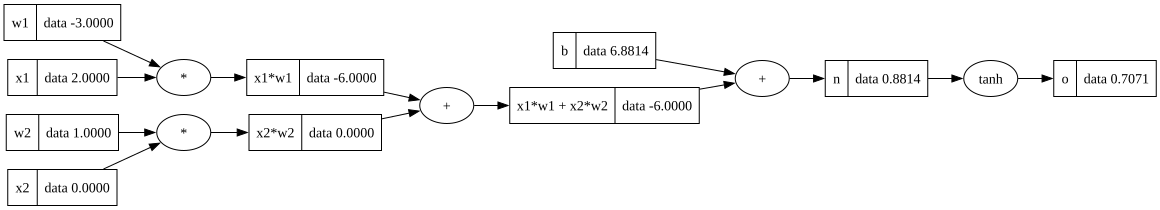

In [ ]:
draw_dot(o)

In [ ]:
import torch

In [ ]:
import torch
print(torch.__version__)

2.13.0+cpu


In [ ]:
import torch

# Inputs & Weights
x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True

# Forward pass
n = x1 * w1 + x2 * w2 + b
o = torch.tanh(n)

print("Output o:", o.data.item())

# Backward pass
o.backward()

print("--- Gradients ---")
print("x1 grad:", x1.grad.item())
print("w1 grad:", w1.grad.item())
print("x2 grad:", x2.grad.item())
print("w2 grad:", w2.grad.item())

Output o: 0.7071066904050358
--- Gradients ---
x1 grad: -1.5000003851533106
w1 grad: 1.0000002567688737
x2 grad: 0.5000001283844369
w2 grad: 0.0


In [ ]:
import torch

# Define inputs, weights, and bias as 64-bit PyTorch tensors tracking gradients
x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True

# Forward pass: linear combination followed by tanh activation
n = x1 * w1 + x2 * w2 + b
o = torch.tanh(n)

# Print forward pass output scalar
print(o.data.item())

# Backward pass: compute gradients automatically
o.backward()

# Print calculated gradients
print("---")
print("x2", x2.grad.item())
print("w2", w2.grad.item())
print("x1", x1.grad.item())
print("w1", w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [ ]:
import random


class Neuron:

    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        # w * x + b
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out


class Layer:

    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs


class MLP:

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i + 1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x


x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=-0.36798615025011067)

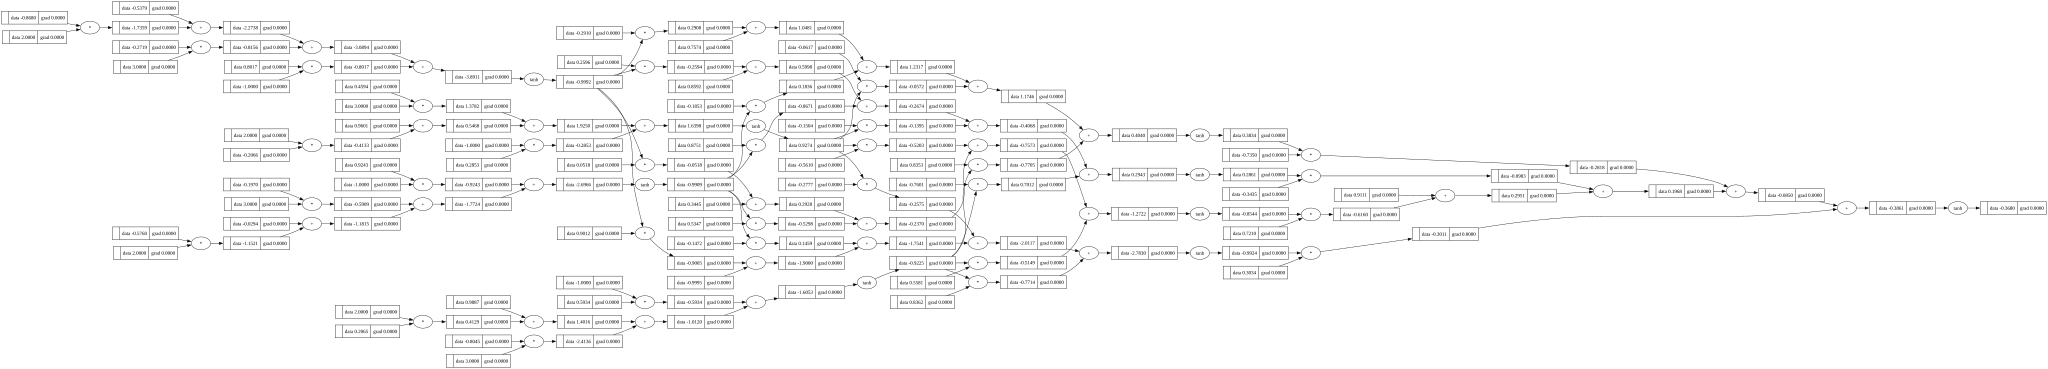

In [54]:
draw_dot(n(x))

In [55]:
import math
import random

# ==========================================
# 1. Complete Value Class
# ==========================================


class Value:

    def __init__(self, data, _children=(), _op="", label=""):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+")

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad

        out._backward = _backward
        return out

    def __radd__(self, other):
        return self + other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self * other

    def __pow__(self, other):
        assert isinstance(
            other, (int, float)
        ), "only supporting int/float powers"
        out = Value(self.data**other, (self,), f"**{other}")

        def _backward():
            self.grad += (other * (self.data ** (other - 1))) * out.grad

        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), "exp")

        def _backward():
            self.grad += out.data * out.grad

        out._backward = _backward
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2 * x) - 1) / (math.exp(2 * x) + 1)
        out = Value(t, (self,), "tanh")

        def _backward():
            self.grad += (1 - t**2) * out.grad

        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()


# ==========================================
# 2. Neural Network Components
# ==========================================


class Neuron:

    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]


class Layer:

    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]


class MLP:

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i + 1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


# ==========================================
# 3. Model & Prediction Execution
# ==========================================
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
output = n(x)

print("Forward pass successful!")
print("Network Output:", output)
print("Total parameters:", len(n.parameters()))

Forward pass successful!
Network Output: Value(data=0.283818413645626)
Total parameters: 41


In [56]:
from graphviz import Digraph


def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format="svg", graph_attr={"rankdir": "LR"})  # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(
            name=uid,
            label="{ %s | data %.4f | grad %.4f }"
            % (n.label if hasattr(n, "label") else "", n.data, n.grad),
            shape="record",
        )
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect it to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

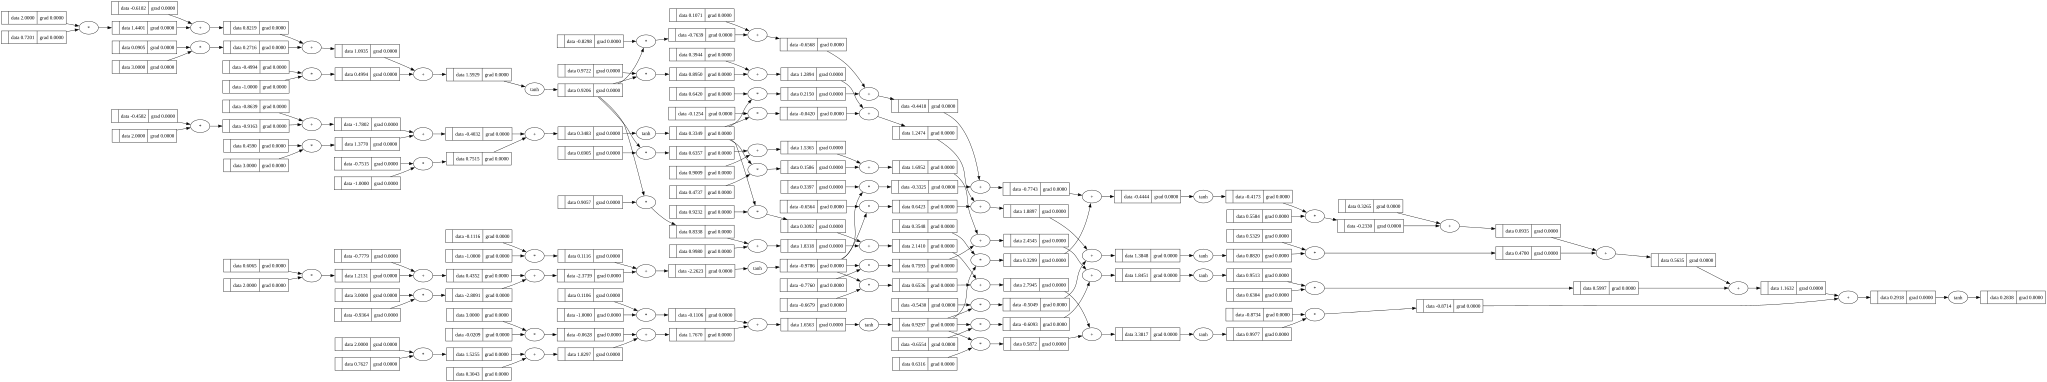

In [57]:
draw_dot(output)

In [60]:
# 1. Dataset & Model setup
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]  # desired targets

n = MLP(3, [4, 4, 1])

# 2. Gradient Descent Optimization Loop
for k in range(20):

    # Forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout + (-ygt)) ** 2 for ygt, yout in zip(ys, ypred))

    # Zero Grad (CRITICAL STEP: flush previous gradients)
    for p in n.parameters():
        p.grad = 0.0

    # Backward pass
    loss.backward()

    # Update weights (Learning rate = 0.05)
    for p in n.parameters():
        p.data += -0.05 * p.grad

    print(f"Step {k+1:2d} | Loss: {loss.data:.6f}")

print("\nFinal Predictions after training:", ypred)
print("Target Ground Truth:            ", ys)

Step  1 | Loss: 6.428932
Step  2 | Loss: 4.580118
Step  3 | Loss: 2.559276
Step  4 | Loss: 1.564875
Step  5 | Loss: 0.923962
Step  6 | Loss: 0.340578
Step  7 | Loss: 0.180985
Step  8 | Loss: 0.144559
Step  9 | Loss: 0.123928
Step 10 | Loss: 0.109235
Step 11 | Loss: 0.097836
Step 12 | Loss: 0.088621
Step 13 | Loss: 0.080983
Step 14 | Loss: 0.074536
Step 15 | Loss: 0.069019
Step 16 | Loss: 0.064241
Step 17 | Loss: 0.060064
Step 18 | Loss: 0.056379
Step 19 | Loss: 0.053105
Step 20 | Loss: 0.050177

Final Predictions after training: [Value(data=0.916376478290148), Value(data=-0.9096411334085727), Value(data=-0.8808305977401075), Value(data=0.8557146221359353)]
Target Ground Truth:             [1.0, -1.0, -1.0, 1.0]
